In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob
from arcgis.gis import GIS
gis = GIS('http://deldev.maps.arcgis.com', 'demos_deldev', 'DelDevs12', verify_cert=False)

In [2]:
from arcgis.features.manage_data import dissolve_boundaries

In [3]:
item = gis.content.get('4e0ad45cc99e4f63ae5fcbc39ad9010d')

In [4]:
buffers = item.layers[0]

In [5]:
import pandas as pd

In [6]:
sdf = pd.DataFrame.spatial.from_layer(buffers)

In [7]:
from datetime import datetime
dissolve = dissolve_boundaries(buffers,
                               output_name='DissolvedLayers' + str(datetime.now().microsecond),
                               multi_part_features=False, future=True)
assert isinstance(dissolve, GPJob)
dissolve

<DissolveBoundaries GP Job: j8be7cbb01f5c4984afb5cbdce1ae5c8b>

In [8]:
dissolve.result()

<Item title:"DissolvedLayers333918" type:Feature Layer Collection owner:demos_deldev>

In [9]:
assert isinstance(dissolve.result(), Item)

In [10]:
dissolve.result().delete()

True

In [12]:
item3 = gis.content.get('d8e6e822e6b44d80b4d3b5fe7538576d')

<Item title:"USA Census Populated Places" type:Feature Layer Collection owner:esri>
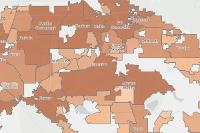

In [13]:
item3

In [14]:
item3.layers

[<FeatureLayer url:"https://services.arcgis.com/P3ePLMYs2RVChkJx/arcgis/rest/services/USA_Census_Populated_Places/FeatureServer/0">]

In [15]:
test3 = dissolve_boundaries(input_layer=item3.layers[0],
                            dissolve_fields=["CLASS","ST"],
                            summary_fields=["POP12_SQMI MEAN"],
                            output_name="DissolveBoundariesTest" + str(datetime.now().microsecond))

In [16]:
test3

<Item title:"DissolveBoundariesTest142548" type:Feature Layer Collection owner:demos_deldev>

In [17]:
test3.delete()

True

In [18]:
item4 = gis.content.get('48f9af87daa241c4b267c5931ad3b226')

<Item title:"USA Counties" type:Feature Layer Collection owner:esri_dm>
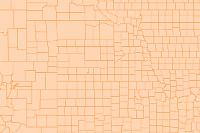

In [19]:
item4

In [20]:
test4 = dissolve_boundaries(input_layer=item4.layers[0],
                            dissolve_fields=["STATE_NAME"],
                            summary_fields=["POPULATION STDDEV"],
                            output_name="DissolveBoundariesTest" + str(datetime.now().microsecond))

In [21]:
test4

<Item title:"DissolveBoundariesTest474809" type:Feature Layer Collection owner:demos_deldev>

In [22]:
test4.delete()

True